# Human Activity Recognition with Wifi

In [16]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from models.Architectures import *
from utilities.training import *
from utilities.plotting import *
from utilities.data_processing import *

from time import time 
from torchvision.transforms import Compose, ToTensor, RandomHorizontalFlip, RandomVerticalFlip
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from glob import glob
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [2]:
DEBUG_MODE                 = True

TRAIN_DATASET_PATH  = "doppler_traces/S1*"
TEST_DATASET_PATH   = "doppler_traces/S2*"
DOPPLER_TRACE_SIZE  = 340

LABELS     = ['W', 'E', 'R', 'J', 'L']
ACTIVITIES = ['Walking', 'Empty', 'Running', 'Jumping', 'Sitting']
labels_map = {label:idx for idx, label in enumerate(LABELS)}

create_train_dataset(TRAIN_DATASET_PATH, DOPPLER_TRACE_SIZE, LABELS)
create_test_dataset(TEST_DATASET_PATH, DOPPLER_TRACE_SIZE, LABELS)

Dataset is already splitted!

Dataset is already splitted!



## Training of SHARP architecure (no batch normalization)

Loading dataset doppler_traces_train in memory...


3256it [00:02, 1315.10it/s]


Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_train
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------

Loading dataset doppler_traces_test in memory...


2816it [00:02, 1328.17it/s]


Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_test
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------



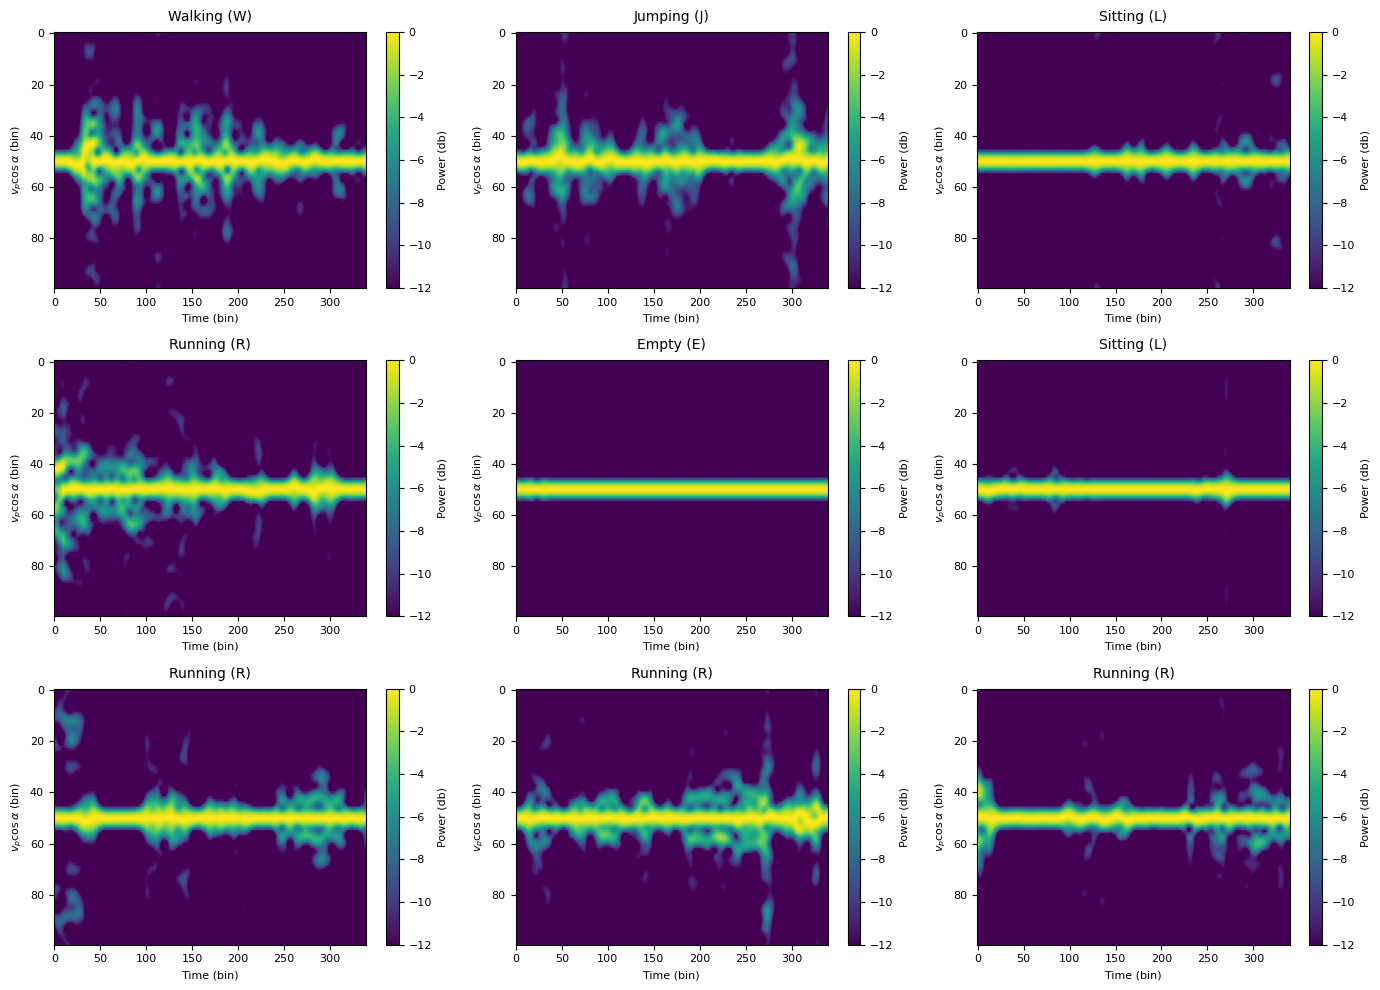

In [3]:
batch_size = 128
train_dataset  = DopplerDataset("doppler_traces_train", labels_map, db_conversion=True, normalization=False)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_dataset.getInfo()

test_dataset  = DopplerDataset("doppler_traces_test", labels_map, db_conversion=True, normalization=False)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
test_dataset.getInfo()

plot_dataset(3, 3, train_dataset, ACTIVITIES, LABELS)

In [4]:
sharp_model = SHARP(n_features=len(ACTIVITIES), batchNorm=False)

learning_rate = 1e-4
device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate)

if DEBUG_MODE:
    #### CHECKING DATA TYPES 
    x, y = next(iter(train_dataloader))
    print(x.dtype)
    print(next(sharp_model.parameters()).dtype)
    ### DEVICE
    print(f"Device: {device}")

torch.float32
torch.float32
Device: mps


In [5]:
epochs = 20
train_loss, test_loss, train_acc, test_acc, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/20 ------ Time (total): 0.00 ------ Time (relative): 0.00

Loss: 1.74215e+00 --- Accuracy: 13.281% --- Samples:   128/ 3256
Loss: 1.58805e+00 --- Accuracy: 20.597% --- Samples:  1408/ 3256
Loss: 1.46072e+00 --- Accuracy: 27.158% --- Samples:  2688/ 3256
Loss: 1.47555e+00 --- Accuracy: 28.471% --- Samples:  3256/ 3256
Test Error: 
 Accuracy: 34.8%, Avg loss: 1.440875 

Completed epochs: 1/20 ------ Time (total): 4.44 ------ Time (relative): 4.44

Loss: 1.45492e+00 --- Accuracy: 32.812% --- Samples:   128/ 3256
Loss: 1.40045e+00 --- Accuracy: 35.156% --- Samples:  1408/ 3256
Loss: 1.38468e+00 --- Accuracy: 35.863% --- Samples:  2688/ 3256
Loss: 1.39265e+00 --- Accuracy: 36.517% --- Samples:  3256/ 3256
Test Error: 
 Accuracy: 43.5%, Avg loss: 1.337486 

Completed epochs: 2/20 ------ Time (total): 7.85 ------ Time (relative): 3.41

Loss: 1.34042e+00 --- Accuracy: 35.156% --- Samples:   128/ 3256
Loss: 1.31021e+00 --- Accuracy: 37.997% --- Sam

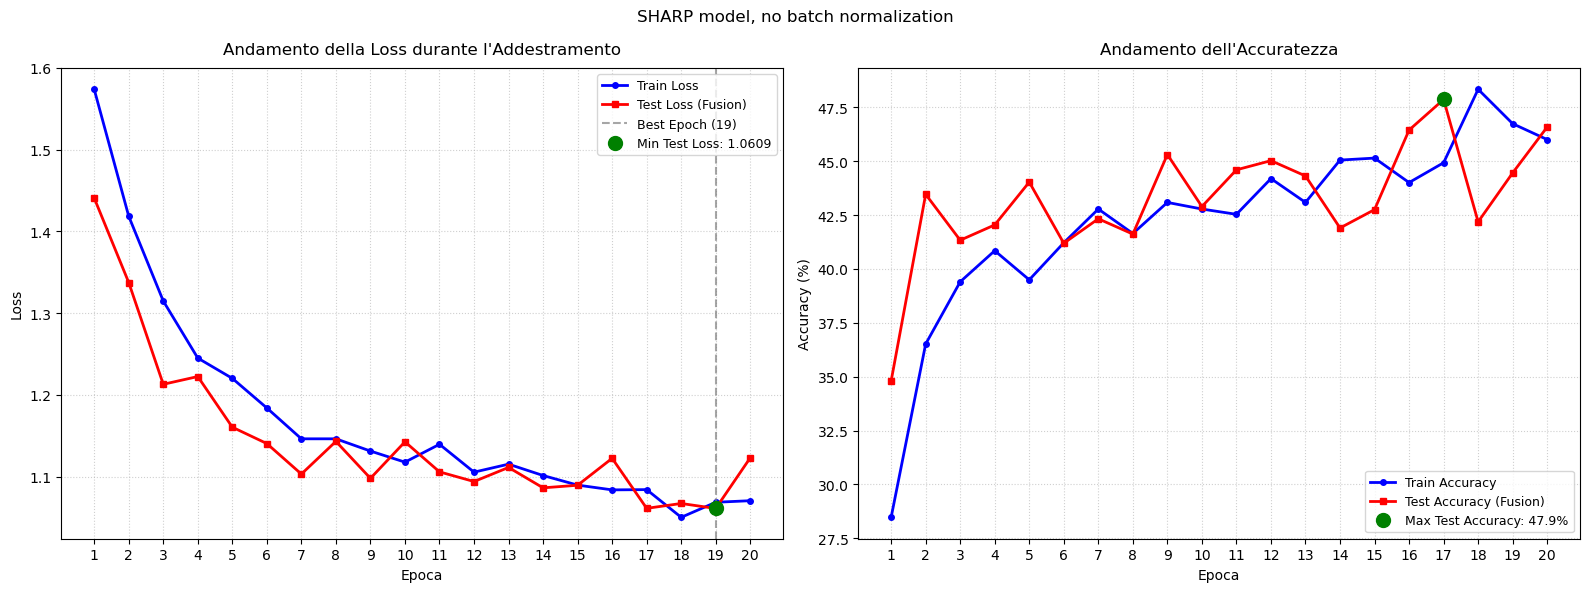

In [6]:
plot_loss(train_loss, test_loss, train_acc, test_acc, "SHARP model, no batch normalization")

### Training of SHARP (with BatchNormalization)

Loading dataset doppler_traces_train in memory...


3256it [00:01, 1635.71it/s]


Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_train
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------

Loading dataset doppler_traces_test in memory...


2816it [00:01, 1507.92it/s]


Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_test
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------



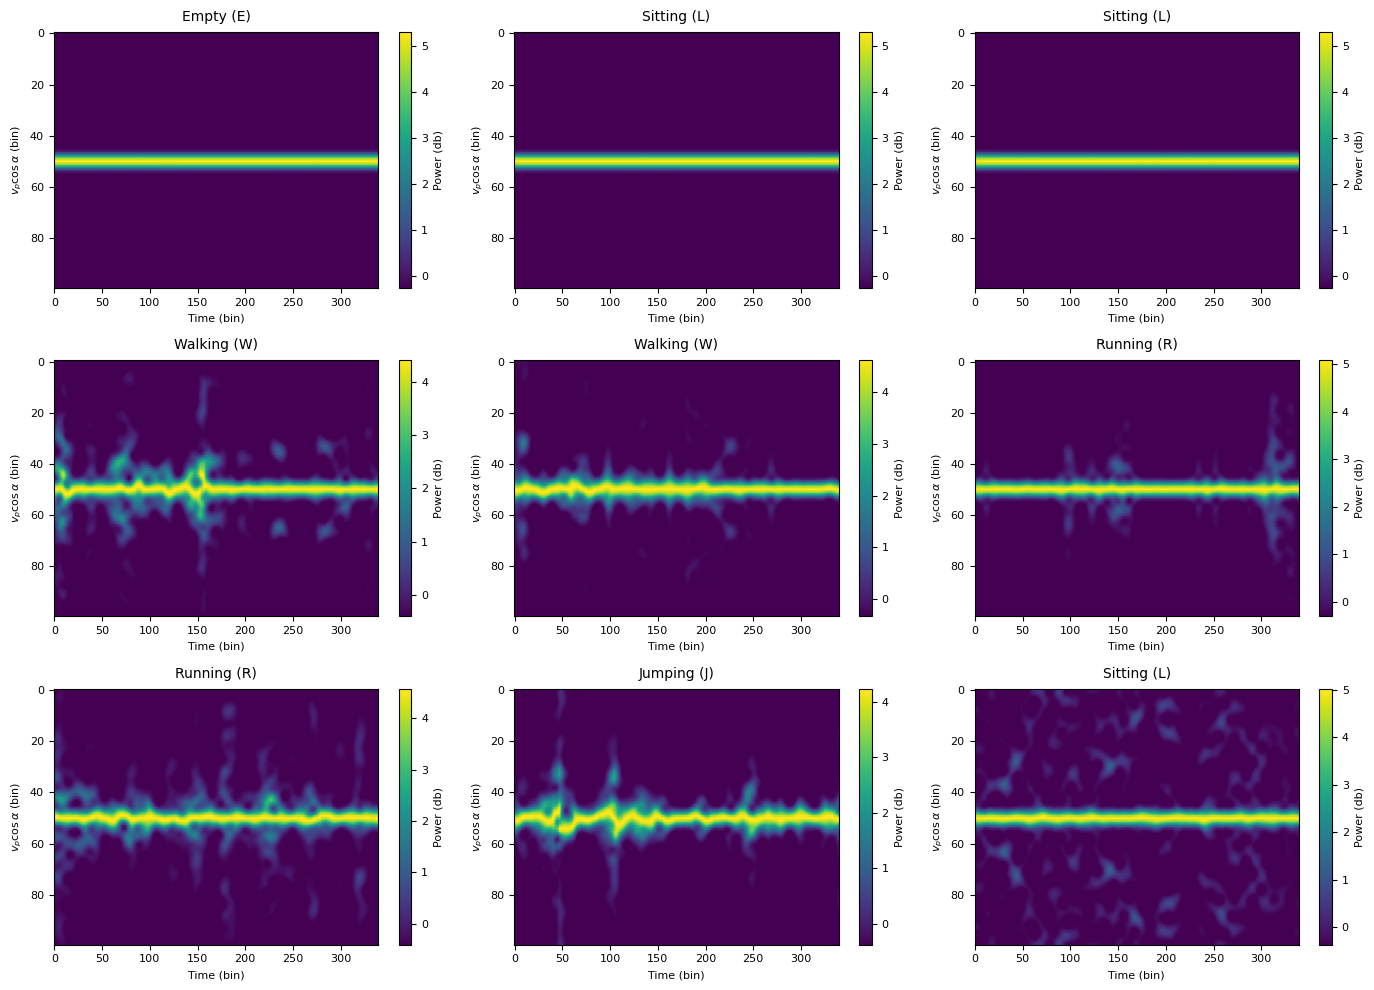

In [7]:
train_dataset  = DopplerDataset("doppler_traces_train", labels_map, db_conversion=False, normalization=True)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_dataset.getInfo()

test_dataset  = DopplerDataset("doppler_traces_test", labels_map, db_conversion=False, normalization=True)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
test_dataset.getInfo()

plot_dataset(3, 3, train_dataset, ACTIVITIES, LABELS)

In [8]:
sharp_model = SHARP(n_features=len(ACTIVITIES), batchNorm=True)

learning_rate = 5e-5
device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate, weight_decay=1e-5)
sharp_model

SHARP(
  (branch1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (branch2): Sequential(
    (0): Conv2dBatchNorm(
      (out): Sequential(
        (0): Conv2d(1, 5, kernel_size=(2, 2), stride=(2, 2))
        (1): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ReLU()
  )
  (branch3): Sequential(
    (0): Conv2dBatchNorm(
      (out): Sequential(
        (0): Conv2d(1, 3, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ReLU()
    (2): Conv2dBatchNorm(
      (out): Sequential(
        (0): Conv2d(3, 6, kernel_size=(2, 2), stride=(1, 1))
        (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (3): ReLU()
    (4): Conv2dBatchNorm(
      (out): Sequential(
        (0): Conv2d(6, 9, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2))
        (1): BatchNor

In [9]:
epochs = 20
train_loss, test_loss, train_acc, test_acc, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/20 ------ Time (total): 0.00 ------ Time (relative): 0.00

Loss: 1.72739e+00 --- Accuracy: 13.281% --- Samples:   128/ 3256
Loss: 1.23375e+00 --- Accuracy: 34.233% --- Samples:  1408/ 3256
Loss: 1.18569e+00 --- Accuracy: 36.719% --- Samples:  2688/ 3256
Loss: 1.08648e+00 --- Accuracy: 37.807% --- Samples:  3256/ 3256
Test Error: 
 Accuracy: 12.4%, Avg loss: 2.871694 

Completed epochs: 1/20 ------ Time (total): 4.79 ------ Time (relative): 4.79

Loss: 1.12801e+00 --- Accuracy: 44.531% --- Samples:   128/ 3256
Loss: 1.13014e+00 --- Accuracy: 46.804% --- Samples:  1408/ 3256
Loss: 1.12267e+00 --- Accuracy: 48.103% --- Samples:  2688/ 3256
Loss: 1.07526e+00 --- Accuracy: 48.096% --- Samples:  3256/ 3256
Test Error: 
 Accuracy: 45.7%, Avg loss: 1.309455 

Completed epochs: 2/20 ------ Time (total): 9.40 ------ Time (relative): 4.61

Loss: 1.04449e+00 --- Accuracy: 46.875% --- Samples:   128/ 3256
Loss: 9.39188e-01 --- Accuracy: 50.781% --- Sam

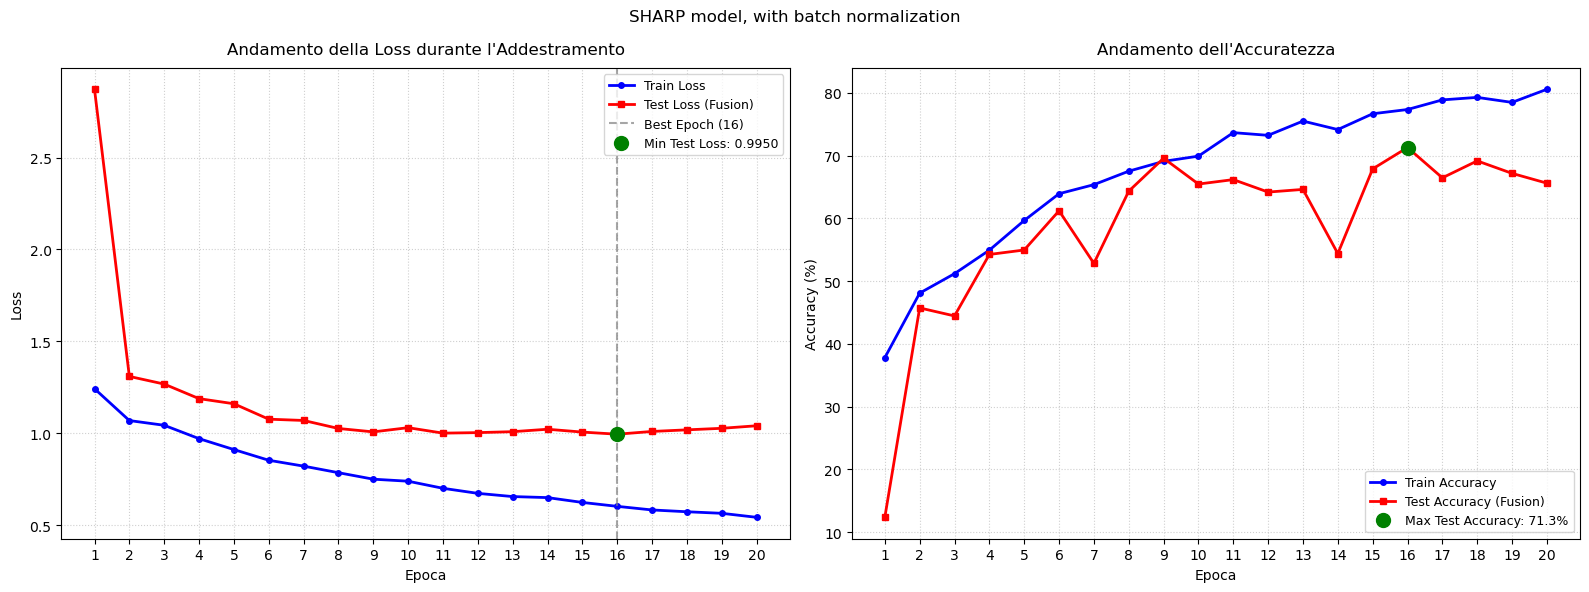

In [10]:
plot_loss(train_loss, test_loss, train_acc, test_acc, "SHARP model, with batch normalization")

## Metrics

In [ ]:
confusion_matrix = compute_confusion_matrix(sharp_model, test_dataset, LABELS, device, True)

100%|██████████| 4/4 [00:00<00:00, 11.54it/s]


Label: W --- Score: 0.35135135135135137
Confusion matrix:
[[0.35135135 0.03603604 0.39414414 0.18468468 0.03378378]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


100%|██████████| 7/7 [00:00<00:00, 33.74it/s]


Label: E --- Score: 0.8507462686567164
Confusion matrix:
[[0.35135135 0.03603604 0.39414414 0.18468468 0.03378378]
 [0.01368159 0.85074627 0.08955224 0.         0.0460199 ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


100%|██████████| 4/4 [00:00<00:00, 37.74it/s]


Label: R --- Score: 0.527027027027027
Confusion matrix:
[[0.35135135 0.03603604 0.39414414 0.18468468 0.03378378]
 [0.01368159 0.85074627 0.08955224 0.         0.0460199 ]
 [0.22747748 0.02027027 0.52702703 0.15765766 0.06756757]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


100%|██████████| 3/3 [00:00<00:00, 35.77it/s]


Label: J --- Score: 0.5304054054054054
Confusion matrix:
[[0.35135135 0.03603604 0.39414414 0.18468468 0.03378378]
 [0.01368159 0.85074627 0.08955224 0.         0.0460199 ]
 [0.22747748 0.02027027 0.52702703 0.15765766 0.06756757]
 [0.21283784 0.01689189 0.14189189 0.53040541 0.09797297]
 [0.         0.         0.         0.         0.        ]]


100%|██████████| 7/7 [00:00<00:00, 32.47it/s]

Label: L --- Score: 0.3695652173913043
Confusion matrix:
[[0.35135135 0.03603604 0.39414414 0.18468468 0.03378378]
 [0.01368159 0.85074627 0.08955224 0.         0.0460199 ]
 [0.22747748 0.02027027 0.52702703 0.15765766 0.06756757]
 [0.21283784 0.01689189 0.14189189 0.53040541 0.09797297]
 [0.00483092 0.60144928 0.01690821 0.00724638 0.36956522]]


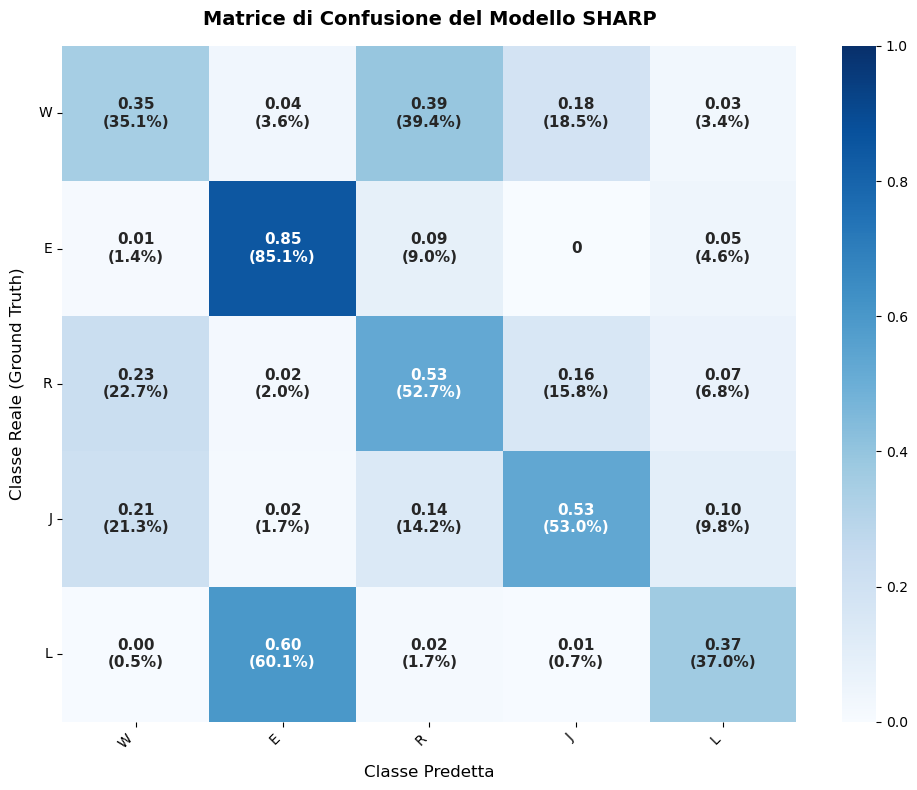

In [20]:
plot_confusion_matrix(confusion_matrix, LABELS)